#### TASK 2 · Unveiling the Android App Market (Google Play Store Analysis)


#### STEP 1– Import Libraries

In [7]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sentiment Analysis
from textblob import TextBlob

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Plot Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
!pip install textblob

#### STEP 2 – Load Both Datasets



In [10]:
import os

print(os.getcwd())

C:\Users\arft


In [11]:
import os

print(os.listdir())

['.cagent', '.conda', '.config', '.docker', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.virtual_documents', '.vscode', '.vscode-shared', '3D Objects', 'anaconda3', 'AppData', 'Application Data', 'beneficiary_summary_table.csv', 'Churn Modelling.ipynb', 'Code_Alpha_iris.ipynb', 'Contacts', 'Cookies', 'covid .codalpha', 'customer segmentation.ipynb', 'Documents', 'Downloads', 'Favorites', 'hbar.png', 'Health_Insurance_Cleaned.csv', 'hira imran', 'Hira Imran health cost predication', 'Hourly Electricity .ipynb', 'IntelGraphicsProfiles', 'Lec-3.09(Pandas-01-From-Python-Dictionary-to-Pandas-Dataframe).ipynb', 'Lec-3.10(Pandas-02-Overview-of-Pandas-Series).ipynb', 'Lec-3.11(Pandas-03-Overview-of-Pandas-Dataframe).ipynb', 'Lec-3.12(Pandas-04-IO-with-CSV-EXCEL-and-JSON-Files).ipynb', 'Lec-3.13(Pandas-05-Subsetting-Dataframes).ipynb', 'Lec-3.14(Pandas-06-Modifying-Dataframes-I).ipynb', 'Lec-3.15(Pandas-07-Modifying-Dataframes-II).ipynb', 'Lec-3.16(Pandas-08-Handling-Missing-D

In [16]:
import pandas as pd

apps = pd.read_csv(r"C:\Users\arft\Downloads\googleplaystore.csv.zip")

apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### Step 3  Initial Dataset Inspection

#### Apps Dataset

In [18]:
apps.shape

(10841, 13)

#### Columns check

In [21]:
apps.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [22]:
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


#### Missing Values

In [23]:
apps.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [26]:
apps = apps.dropna(
    subset=['Rating', 'Android Ver', 'Current Ver', 'Content Rating']
)

In [27]:
apps.isnull().sum()



App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

#### Step 4 — Data Cleaning

####  Remove Duplicate Apps

In [28]:
apps.duplicated().sum()

np.int64(474)

In [29]:

apps = apps.drop_duplicates()

In [30]:
apps.duplicated().sum()

np.int64(0)

#### Step 5  Convert Installs Column

In [32]:
apps['Installs'] = apps['Installs'].str.replace(',','')
apps['Installs'] = apps['Installs'].str.replace('+','')

apps['Installs'] = apps['Installs'].astype(int)

In [33]:
apps['Installs'].dtype

dtype('int64')

#### Step 6  Convert Price Column

In [34]:
apps['Price'] = apps['Price'].str.replace('$','')

apps['Price'] = apps['Price'].astype(float)

#### Step 7 Convert Size Column

In [43]:
apps['Size'].head(10)

0     19
1     14
2    8.7
3     25
4    2.8
5    5.6
6     19
7     29
8     33
9    3.1
Name: Size, dtype: object

In [45]:
apps['Size'].isnull().sum()

np.int64(1468)

In [46]:
apps['Size'].dtype

dtype('O')

In [47]:
type(apps['Size'])

pandas.core.series.Series

In [48]:
apps.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [49]:
apps['Reviews'].head()

0       159
1       967
2     87510
3    215644
4       967
Name: Reviews, dtype: object

In [50]:
apps['Reviews'] = apps['Reviews'].astype(int)

In [51]:
apps['Reviews'].dtype

dtype('int64')

In [52]:
apps['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [54]:
apps['Installs'] = apps['Installs'].astype(int)

In [55]:
apps['Installs'].dtype

dtype('int64')

In [56]:
apps.dtypes

App                object
Category           object
Rating            float64
Reviews             int64
Size               object
Installs            int64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [57]:
apps['Size'].head(10)

0     19
1     14
2    8.7
3     25
4    2.8
5    5.6
6     19
7     29
8     33
9    3.1
Name: Size, dtype: object

In [58]:
def convert_size(size):
    if pd.isna(size):
        return np.nan
    
    if size == 'Varies with device':
        return np.nan
    
    if 'M' in str(size):
        return float(str(size).replace('M',''))
    
    if 'k' in str(size):
        return float(str(size).replace('k','')) / 1024
    
    return np.nan

In [59]:
apps['Size'] = apps['Size'].apply(convert_size)

In [60]:
apps['Size'].dtype

dtype('float64')

#### Step 8 — Category Analysis

In [61]:
category_count = apps['Category'].value_counts()

category_count.head()

Category
FAMILY          1717
GAME            1074
TOOLS            733
PRODUCTIVITY     334
FINANCE          317
Name: count, dtype: int64

#### Visualization:

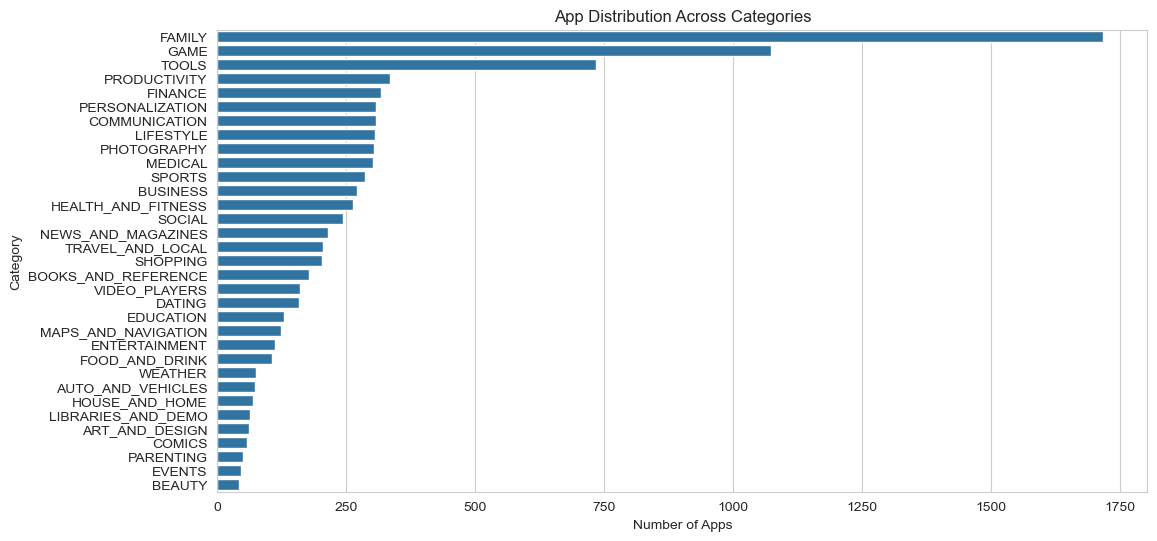

In [62]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_count.values,
    y=category_count.index
)

plt.title("App Distribution Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.show()

#### Step 9  Ratings Analysis

####  Rating Distribution

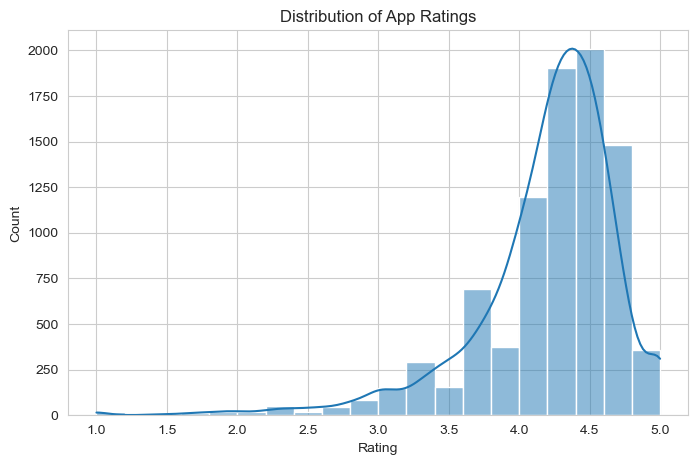

In [63]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps['Rating'],
    bins=20,
    kde=True
)

plt.title("Distribution of App Ratings")

plt.show()

#### Average Rating By Category

avg_rating = apps.groupby('Category')['Rating'].mean().sort_values()

avg_rating

#### Plot:

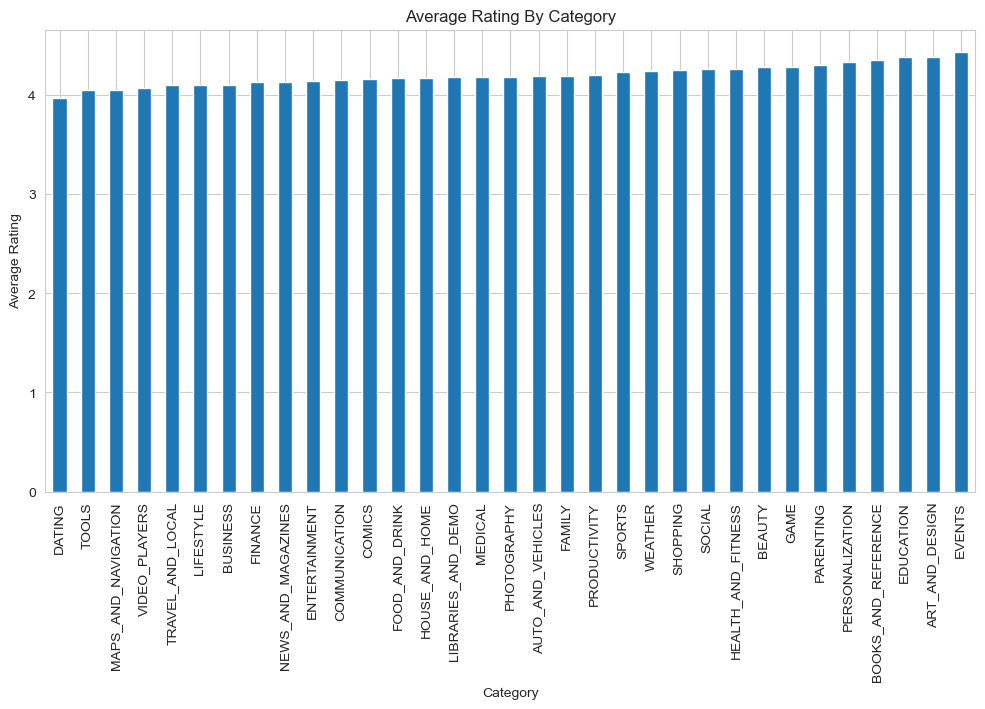

In [66]:
plt.figure(figsize=(12,6))

avg_rating.plot(kind='bar')

plt.title("Average Rating By Category")

plt.ylabel("Average Rating")

plt.show()

#### Step 10 Size vs Installs Analysis

#### Scatter Plot:

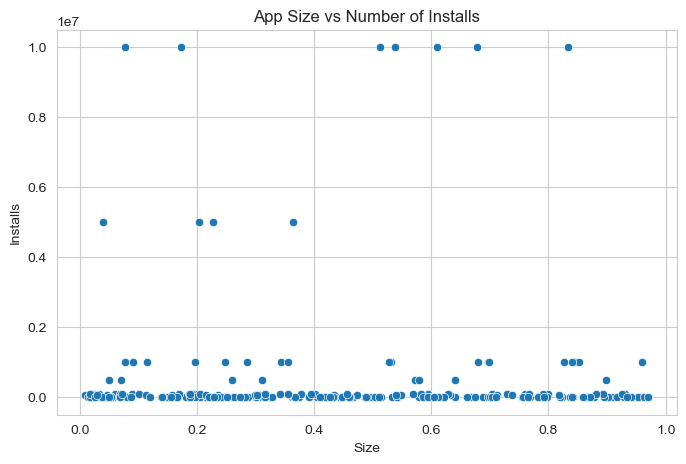

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=apps,
    x='Size',
    y='Installs'
)

plt.title("App Size vs Number of Installs")

plt.show()

#### Insight:

#### Bigger apps don't always mean more installs

#### Step 11 — Pricing Analysis

#### Free vs Paid Apps

In [68]:
apps['Type'] = np.where(
    apps['Price']==0,
    'Free',
    'Paid'
)

In [69]:
apps['Type'].value_counts()

Type
Free    8275
Paid     611
Name: count, dtype: int64

#### Plot:

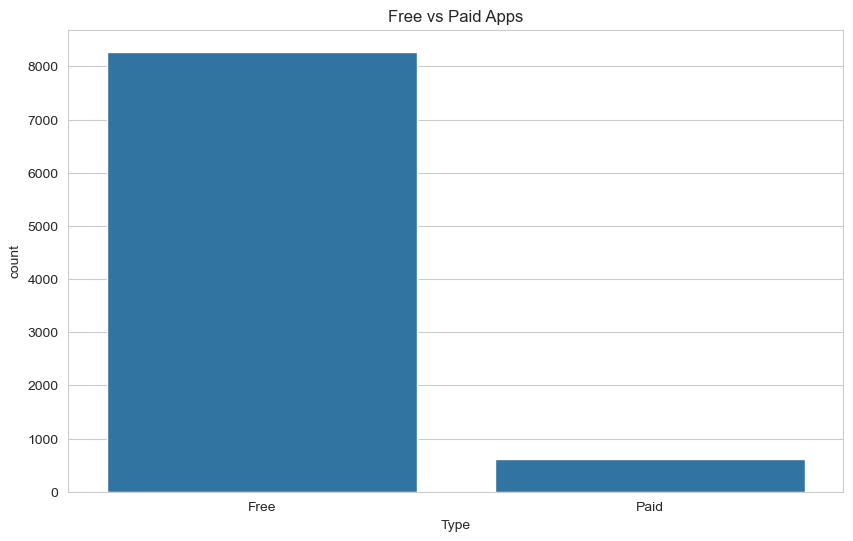

In [70]:
sns.countplot(
    data=apps,
    x='Type'
)

plt.title("Free vs Paid Apps")

plt.show()

#### Step 12  Paid Apps Price Distribution

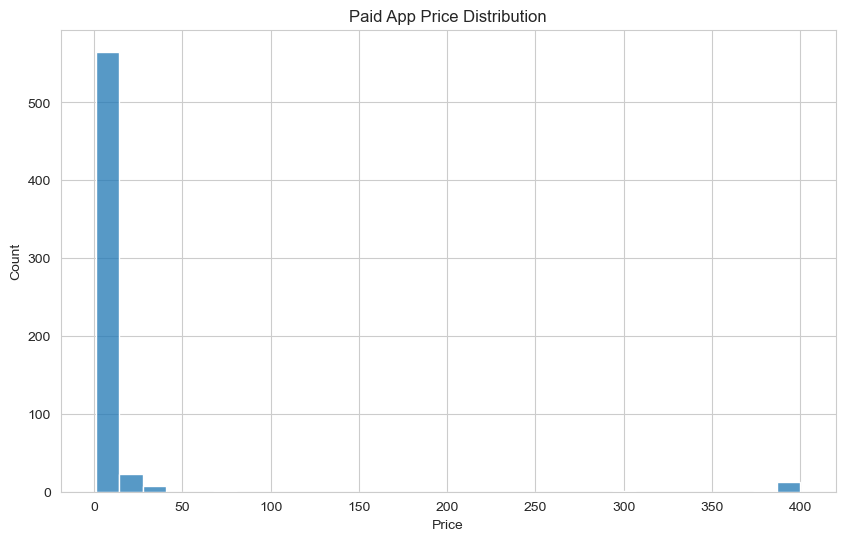

In [71]:
paid_apps = apps[apps['Price']>0]

sns.histplot(
    paid_apps['Price'],
    bins=30
)

plt.title("Paid App Price Distribution")

plt.show()

#### Step 13  Sentiment Analysis

In [72]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [73]:
from textblob import TextBlob

In [88]:
import os

os.listdir(r"C:\Users\arft\Downloads")

['.ipynb_checkpoints',
 '01.jpg',
 '02.jpg',
 '03.jpg',
 '04.jpg',
 '05.jpg',
 '06.jpg',
 '07.jpg',
 '08.jpg',
 '09.jpg',
 '097.jpg',
 '10.jpg',
 '11.jpg',
 '1104745573.pdf',
 '114(1) (Return of Income filed voluntarily for complete year)_2025.pdf',
 '12.jpg',
 '13.jpg',
 '14.jpg',
 '15.jpg',
 '16.jpg',
 '1684579848923.jpg',
 '17.jpg',
 '1782302326317.jpg',
 '18.jpg',
 '19.jpg',
 '20.jpg',
 '21.jpg',
 '22.jpg',
 '23.jpg',
 '34.jpg',
 '365 (1).txt',
 '365 Corp. Credentials (1).txt',
 '365 Corp. Credentials.txt',
 '365.txt',
 '5optx9esukm-data-analyst-job-outlook-thumbnail-v1.jpg',
 '7203021.pdf',
 '747.JPG.jpeg',
 '74701.JPG.jpeg',
 '7h.jpg',
 'archive (1).zip',
 'archive (2).zip',
 'archive (3).zip',
 'archive (4)',
 'archive (4).zip',
 'archive (5).zip',
 'archive (6)',
 'archive (6).zip',
 'archive (7)',
 'archive (7).zip',
 'archive.zip',
 'Armaforcast.jpg',
 'Assignment # 02 (1).pdf',
 'Assignment # 02.pdf',
 'Assignment (1).xlsx',
 'Assignment (2).xlsx',
 'Assignment (3).xlsx',
 '

In [89]:
reviews = pd.read_csv(r"C:\Users\arft\Downloads\googleplaystore_user_reviews.csv")

In [90]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [91]:
reviews.shape

(64295, 5)

In [92]:
reviews.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [93]:
reviews = reviews.dropna(subset=['Translated_Review'])

In [94]:
reviews = reviews.dropna()

In [95]:
def sentiment_analysis(text):
    score = TextBlob(text).sentiment.polarity
    
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

In [96]:
reviews['Sentiment'] = reviews['Translated_Review'].apply(sentiment_analysis)

In [98]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000


#### Step 14 Sentiment Distribution

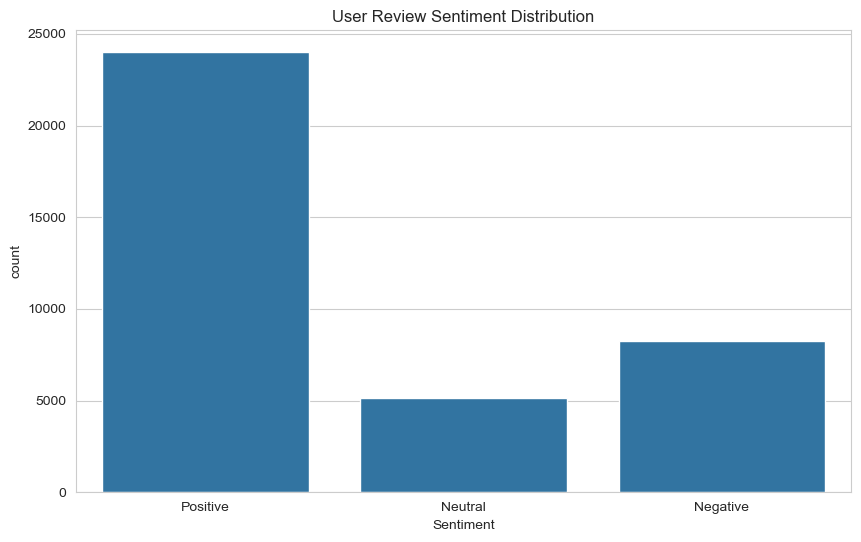

In [99]:
sns.countplot(
    data=reviews,
    x='Sentiment'
)

plt.title("User Review Sentiment Distribution")

plt.show()

#### Step 15 Merge Reviews With Apps

In [100]:
merged = apps.merge(
    reviews,
    on='App',
    how='inner'
)

#### Step 16 Sentiment By Category

In [101]:
category_sentiment = merged.groupby(
    ['Category','Sentiment']
).size().unstack()


category_sentiment.head()

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,61,62,259
AUTO_AND_VEHICLES,17,36,236
BEAUTY,65,88,185
BOOKS_AND_REFERENCE,134,130,551
BUSINESS,342,555,1450


#### Plot

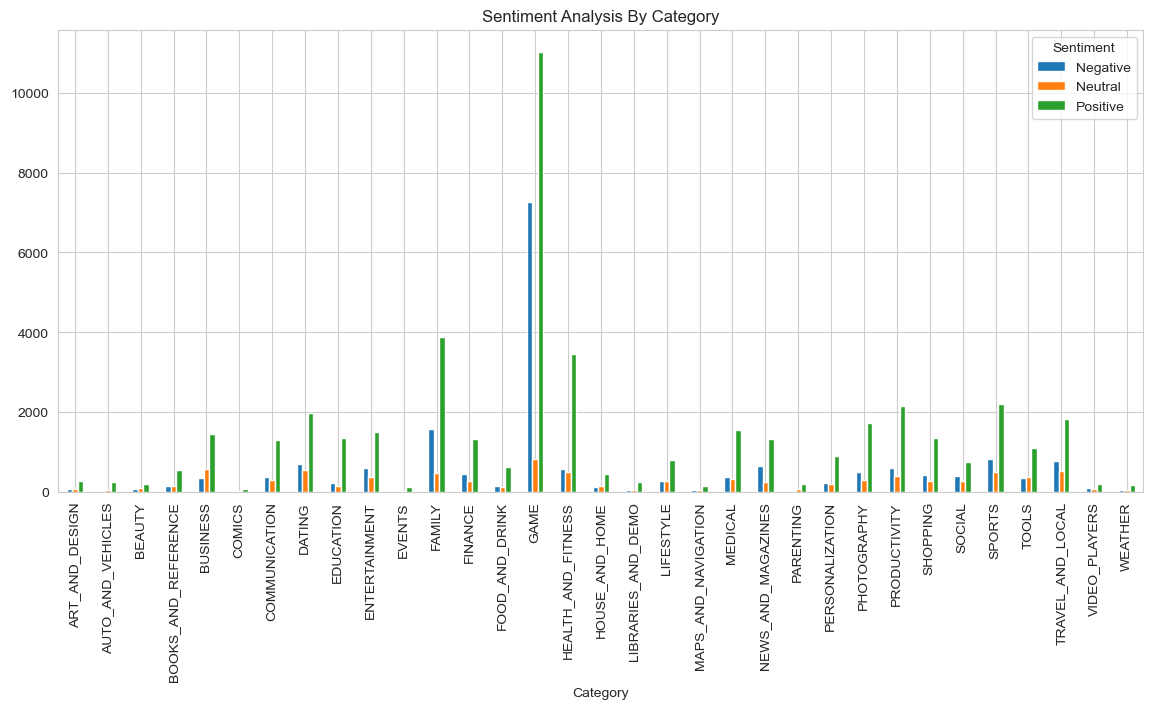

In [102]:
category_sentiment.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title("Sentiment Analysis By Category")

plt.show()

#### Step 17 Interactive Visualization (Plotly)

In [103]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [104]:
import plotly.express as px

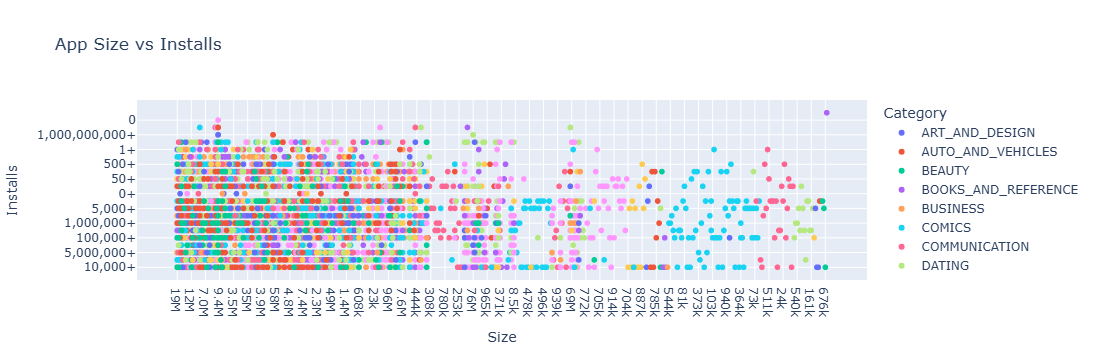

In [106]:
fig = px.scatter(
    apps,
    x="Size",
    y="Installs",
    color="Category",
    title="App Size vs Installs"
)

fig.show()

#### Step 18  Conclusion

#### Gaming and Family categories have the highest number of apps, showing strong competition.
#### Most apps are free, while paid apps represent a very small market segment.
####  Apps with higher user ratings generally receive better user engagement and downloads.